<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter8/8_2_%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#데이터 가져오기
from torchvision.datasets import FashionMNIST

fm_train = FashionMNIST(root='.', train=True, download=True)
fm_test = FashionMNIST(root='.', train=False, download=True)

train_input = fm_train.data
train_target = fm_train.targets

#전처리(케라스와 다른점은 채널차원이 배치차원 바로 다음에 올것)
train_scaled = train_input.reshape(-1, 1, 28, 28) /255.0

In [14]:
#검증세트 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size = 0.2, random_state=42)

In [18]:
#add()처럼 add_module 사용하기
#합성곱층
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
model.add_module('reul1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

In [19]:
#합성곱층 2
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('reul2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
#마지막에는 1차원으로 변환
model.add_module('flatten', nn.Flatten())

In [21]:
#크기를 편리하게 찾는법(1로 채운 배열을 만들어전달)
import torch
outputs = model(torch.ones(1,1,28,28))
print(outputs.shape)
#이값을 Linear층의 입력크기로 사용

torch.Size([1, 3136])


In [22]:
#밀집층과 출력층
model.add_module('dense1', nn.Linear(3136, 100))
model.add_module('reul3', nn.ReLU())
model.add_module('dropout', nn.Dropout())
model.add_module('dense2', nn.Linear(100, 10))

In [23]:
#GPU로 모델 전달 후 손실함수와 옵티마이저 준비
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [25]:
#훈련세트와 검증세트로 각각 데이터셋을 만들고 이를 사용해 배치 크기 32인 데이터로더를 만드는 과정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle= False)


In [30]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss/len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_cnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.3078, 검증 손실:0.2587
에포크:2, 훈련 손실:0.2820, 검증 손실:0.2421
에포크:3, 훈련 손실:0.2643, 검증 손실:0.2420
에포크:4, 훈련 손실:0.2486, 검증 손실:0.2280
에포크:5, 훈련 손실:0.2370, 검증 손실:0.2233
에포크:6, 훈련 손실:0.2252, 검증 손실:0.2239
에포크:7, 훈련 손실:0.2124, 검증 손실:0.2231
에포크:8, 훈련 손실:0.2037, 검증 손실:0.2288
에포크:9, 훈련 손실:0.1922, 검증 손실:0.2184
에포크:10, 훈련 손실:0.1850, 검증 손실:0.2211
에포크:11, 훈련 손실:0.1787, 검증 손실:0.2233
11번째 에포크에서 조기 종료되었습니다.


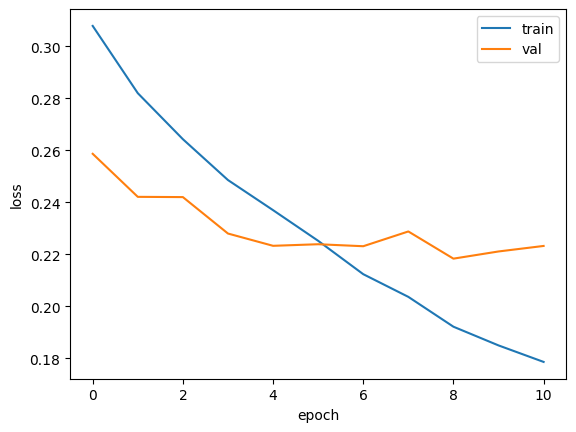

In [31]:
#훈련손실과 검증 손실을 그래프로 그리기
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [32]:
#훈련과정에 저장한 파일을 다시 로드하여 검증세트에 대한 정확도 확인
model.load_state_dict(torch.load('best_cnn_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
  for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            predicts = torch.argmax(outputs, 1)
            corrects += (predicts == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증정확도: {accuracy:.4f}")

검증정확도: 0.9218


In [33]:
#훈련세트에 대한 정확도 계산
test_scaled = fm_test.data.reshape(-1, 1, 28, 28) / 255.0
test_target = fm_test.targets

test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.9130
